<div class='heading'>
    <div style='float:left;'><h1>CPSC 8810 Machine Learning for Graphs</h1></div>
     <img style="float: right; padding-right: 10px" width="100" src="https://raw.githubusercontent.com/bsethwalker/clemson-cs4300/main/images/clemson_paw.png"> </div>
     </div>

**Clemson University**<br>
**Fall 2025**<br>
**Instructor(s):** Aaron Masino <br>

## Homework 2: Shallow Network Embeddings
This homework is intended to assess your knowledge of core elements of shallow node embedding algorithms, application of shallow node embeddings in machine learning tasks, and elements of the PyTorch Geometric implemenation of shallow embedding methods as introduced during the in-class lectures and labs. You may wish to refer to the course lectures and labs while completing this assignment.

**Unless otherwise noted in the problem instructions you may use any of the following Python libraries to complete the exercises:**
- numpy, scipy
- scikit-learn
- matplotlib, seaborn, pygraphviz
- PyTorch, PyTorch Geometric
- NetworkX


In [ ]:
# Google Colab setup
# mount the google drive - this is necessary to access supporting src
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/ml4g/data"

In [ ]:
# install missing libraries (this may take several minutes)
!pip3 install torch_geometric
!pip install torch-cluster

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from IPython import display
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import Node2Vec
from torch_geometric.transforms import RandomNodeSplit
from torch import nn as tnn
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)

RANDOM_STATE = 123456
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Helper Functions
The functions in the following cell are helper methods that will be used in exercises below. These will be noted when needed.

In [ ]:
##################################
#### DO NOT MODIFY THIS CODE #####
##################################
def generate_undirected_adj_matrix(n, p=0.2, rs=RANDOM_STATE):
    """Generate a random adjacency matrix for an undirected graph with n nodes and edge probability p."""
    G = nx.gnp_random_graph(n, p, directed=False, seed=rs)
    return nx.to_numpy_array(G, dtype=int)

def convert_adj_matrix_to_adj_list(adj_matrix):
    """Convert an adjacency matrix to an adjacency list."""
    adj_list = {}
    for i in range(adj_matrix.shape[0]):
        adj_list[i] = list(np.where(adj_matrix[i] == 1)[0].tolist())
    return adj_list

def generate_undirected_adj_list(n, p=0.2, rs=RANDOM_STATE):
    """Generate a random adjacency list for an undirected graph with n nodes and edge probability p."""
    adj_matrix = generate_undirected_adj_matrix(n, p, rs)
    return convert_adj_matrix_to_adj_list(adj_matrix)

def simulate_udirected_graph(num_nodes, p=0.2, rs=RANDOM_STATE):
    """Generate a random undirected graph with n nodes and edge probability p."""
    G = nx.from_dict_of_lists(generate_undirected_adj_list(num_nodes, p, rs))
    return G

def generate_simulated_graphs(num_graphs, num_nodes, p_vals=[0.2], initial_seed=RANDOM_STATE):
    dataset = []
    labels = []
    cnt = 0
    for idx, p in enumerate(p_vals):
        for _ in range(num_graphs):  # Generate 10 graphs for each probability
            dataset.append(simulate_udirected_graph(num_nodes, p, rs=initial_seed+cnt))
            labels.append(idx)
            cnt += 1
    class_names = [f'C{_}' for _ in range(len(np.unique(labels)))]  # Create class names based on unique labels
    return dataset, np.array(labels), class_names

def node_random_choice(nodes, probs=None):
    if probs is None or np.std(probs) == 0:
        return np.random.choice(nodes)
    else:
        return np.random.choice(nodes, p=probs)

def barbell_network(num_nodes, num_border_nodes=2):
    adj_list = {}
    for i in range(num_nodes-1):
        if i == 0:
            adj_list[i] = [1]
            border_nodes = [num_nodes+_ for _ in range(num_border_nodes)]
            adj_list[i].extend(border_nodes) # First node connects to the next and border nodes
            for bn in border_nodes:
                adj_list[bn] = [0]
        else:
            adj_list[i] = [i-1, i+1]
    adj_list[num_nodes-1] = [num_nodes-2]
    border_nodes = [num_nodes+num_border_nodes+_ for _ in range(num_border_nodes)]
    adj_list[num_nodes-1].extend(border_nodes)  # Last node only connects to the previous one
    for bn in border_nodes:
        adj_list[bn] = [num_nodes-1]
    return adj_list


---

# Exercise 1:  Unbiased Random Walk (2 points)
In this exercise, you are asked to implement an ubiased random walk policy. The unbiased random walk should select the next node in the walk from the neighbors of the current node with equal probability. In the code cell below, complete the implementation of the `unbiased_step` method. The method takes as input:
- `adj_list` : a dictionary representing the adjacency list of the graph
- `current_node` : the ID (adj_list key) for the current node in the walk

The method should return the next node in the random walk. Edge case: If the curent node has no neighbors (e.g., the code is in its own component or the input graph is connected and the current node has only inward links), the method should return the current node.

HINT: Use the `node_random_choice` method defined in the Helper functions. This is a modified version of [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html). The reason for the modified version is that np.random.choice uses different algorithms for selecting a random choice when using the default uniform random distribution vs. when a distribution (p) is given as input even if the input, p, is equivalent to a uniform distribution. In a later exercise, we will want the random choice behavior to be the same as the default in this case.

In [ ]:
def unbiased_step(adj_list, current_node):
    ### YOUR CODE HERE ###
    pass

In [ ]:
# assertion tests
adj_list = {0:[1,2], 1:[0,2], 2:[0,1], 4:[]}
assert unbiased_step(adj_list, 0) in [1,2]
assert unbiased_step(adj_list, 1) in [0,2]
assert unbiased_step(adj_list, 2) in [0,1]
assert unbiased_step(adj_list, 4) == 4  # No neighbors, should return current node
l = [unbiased_step(adj_list, 0) for _ in range(1000)]
assert np.isclose(np.mean(l), 1.5, atol=0.1), "The unbiased step should return one of the neighbors with equal probability"


---

# Excersie 2: Biased Random Walk (4 points)
In this exercise, you are asked to implement the biased random walk policy used introduced in the _node2vec_ method. The exercise has three parts:
* (a)(2 points) Implement a method for computing the **unnormalized** transition probabilities for the next node in the random walk using the node2vec biased random walk policy
* (b)(1 point) Implement a method to compute the **normalized** transition probabilities for the next node in the random walk using the node2vec biased random walk policy
* (b)(1 point) Implement a method to select the next node in the biased random walk based on the node2vec

### 2(a). Unnormalized transition probabilities
In the code cell below, implment the method `unnormalized_transition_probabilities`. Assume that the input graph is _un-weighted_, i.e. assume $w_{vx}=1$ for all nodes $v$ and $x$. The method takes as input:
* `adj_list` : a dictionary representing the adjacency list of the graph
* `current_node` : the ID (adj_list key) for the current node in the walk
* `previous_node` : the ID for the previous node in the walk
* `p` : the return parameter
* `q` : the in-out parameter

The method should return a dictionary with keys that are the IDs of the neighbors of the current node and values that are the **unnormalized** transition probability to the neighbor node. Be sure to handle the the initial step, where previous node is None. In the edge case where the current node has no neighbors, the method should return {current_node:1}. What should your method do if `p==0` or `q==0`? HINT: See Python [ValueError](https://docs.python.org/3/library/exceptions.html#ValueError)

In [ ]:
def unnormalized_transition_probabilities(adj_list, current_node, previous_node, p, q):
    ### YOUR CODE HERE ###
    pass

In [ ]:
# assertion tests
adj_list = {'t':['v', 'x1', 'x4'], 'v':['t', 'x1', 'x2', 'x3'], 'x1':['t', 'v'], 'x2':['v'], 'x3':['v'],'x4':[]}
p = 3
q = 2
assert np.isclose(unnormalized_transition_probabilities(adj_list, 'v', 't', p, q)['t'], 1/p)
assert unnormalized_transition_probabilities(adj_list, 'v', 't', p, q)['x1'] == 1
assert np.isclose(unnormalized_transition_probabilities(adj_list, 'v', 't', p, q)['x2'], 1/q)
assert np.isclose(unnormalized_transition_probabilities(adj_list, 'v', 't', p, q)['x3'], 1/q)
assert unnormalized_transition_probabilities(adj_list, 'x4', 't', p, q)['x4'] == 1  # No neighbors, should stay where it is
for k in adj_list['t']:
    assert unnormalized_transition_probabilities(adj_list, 't', None, p, q)[k] == 1  # Should not error out

### 2(b). Normalized transition probabilities
In the code cell below, implment the method `normalized_transition_probabilities`. Assume that the input graph is _un-weighted_, i.e. assume $w_{vx}=1$ for all nodes $v$ and $x$. The method takes as input:
* `adj_list` : a dictionary representing the adjacency list of the graph
* `current_node` : the ID (adj_list key) for the current node in the walk
* `previous_node` : the ID for the previous node in the walk
* `p` : the return parameter
* `q` : the in-out parameter

The method should return a dictionary with keys that are the IDs of the neighbors of the current node and values that are the **normalized** transition probability to the neighbor node.

Your solution should use the `unnormalized_transition_probabilities` method from the previous step.

In [ ]:
def normalized_transition_probabilities(adj_list, current_node, previous_node, p, q):
    ### YOUR CODE HERE ###
    pass

In [ ]:
# assertion tests
adj_list = {'t':['v', 'x1'], 'v':['t', 'x1', 'x2', 'x3'], 'x1':['t', 'v'], 'x2':['v'], 'x3':['v']}
p = 3
q = 2
d = sum(unnormalized_transition_probabilities(adj_list, 'v', 't', p, q).values())
assert np.isclose(normalized_transition_probabilities(adj_list, 'v', 't', p, q)['t'], 1/p/d)
assert np.isclose(normalized_transition_probabilities(adj_list, 'v', 't', p, q)['x1'], 1/d)
assert np.isclose(normalized_transition_probabilities(adj_list, 'v', 't', p, q)['x2'], 1/q/d)
assert np.isclose(normalized_transition_probabilities(adj_list, 'v', 't', p, q)['x3'], 1/q/d)

### 2(c). Biased step
In the code cell below, implment the method `biased_step`. Assume that the input graph is _un-weighted_, i.e. assume $w_{vx}=1$ for all nodes $v$ and $x$. The method takes as input:
* `adj_list` : a dictionary representing the adjacency list of the graph
* `current_node` : the ID (adj_list key) for the current node in the walk
* `previous_node` : the ID for the previous node in the walk
* `p` : the return parameter
* `q` : the in-out parameter

The method should return the next node in the biased random walk.

HINT: Review [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html)

Your solution should use the `normalized_transition_probabilities` method from the previous step.

HINT: Use the `node_random_choice` method defined in the Helper functions. This is a modified version of [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html). The reason for the modified version is that np.random.choice uses different algorithms for selecting a random choice when using the default uniform random distribution vs. when a distribution (p) is given as input even if the input, p, is equivalent to a uniform distribution. In a later exercise, we will want the random choice behavior to be the same as the default in this case.

In [ ]:
def biased_step(adj_list, current_node, previous_node, p, q):
    ### YOUR CODE HERE ###
    pass

In [ ]:
adj_list = {'t':['v', 'x1'], 'v':['t', 'x1', 'x2', 'x3'], 'x1':['t', 'v'], 'x2':['v'], 'x3':['v'], 'x4':[]}
p = 1
q = 1
assert biased_step(adj_list, 't', 'v', p, q) in ['v', 'x1']
assert biased_step(adj_list, 'v', 't', p, q) in ['t', 'x1','x2', 'x3']
assert biased_step(adj_list, 'x1', 't', p, q) in ['t', 'v']
assert biased_step(adj_list, 'x4', 't', p, q) == 'x4'  # No neighbors, should return current node

---
# Exercise 3: Empirical Analysis of Random Walks with Node2Vec Comparison (10 points)
In this exercise, you are asked to implement an empirical analysis of the behavior of random walks. The exercise has four parts:
* (a)(3 points) Implement the random walk method
* (b)(3 points) Implement the empirical distribution method
* (c)(2 points) Demonstrate the settings under which the unbiased and biased random walks are the same
* (d)(2 points) Demonstrate the empirical probability of visiting a distant node vs. a nearby node in biased walks

### 3(a) Random walk implementation
In the code cell below, implement the method `random_walk`. Assume that the input graph is _un-weighted_, i.e. assume $w_{vx}=1$ for all nodes $v$ and $x$. The method takes as input:
* `adj_list` : a dictionary representing the adjacency list of the graph
* `start_node` : the ID (adj_list key) of the starting node for the walk
* `num_steps` : the number of steps in the walk
* `biased` : a boolean parameter, if True the walk shold be a biased walk, if False it should be an unbiased walk
* `p` : the return parameter if using a biased walk
* `q` : the in-out parameter if using an unbiased walk

The method should return a list that are the nodes in the walk. It should contain the `start_node` as the first element. If `biased==False`, your method should call `unbiased_step` and if `biased==True` it should call `biased_step`. We'll see in part (c), that we really only need the `biased_step` function.

Note, the `random_walks` method has been implemented for you. It should **not** be modified.

In [ ]:
def random_walk(adj_list, start_node, num_steps, biased=False, p=None, q=None):
    ### YOUR CODE HERE ###
    pass

##################################
#### DO NOT MODIFY THIS CODE #####
##################################
def random_walks(g, start_node, num_steps, num_walks, biased=False, p=None, q=None):
    np.random.seed(RANDOM_STATE)
    return [random_walk(g, start_node, num_steps, biased, p, q) for _ in range(num_walks)]

### 3(b) Empirical distribution implementation
In the code cell below, implement the method `empirical_distribution`. Assume that the input graph is _un-weighted_, i.e. assume $w_{vx}=1$ for all nodes $v$ and $x$. The method takes as input:
* `walks` : a list where each element is a list that represents a random walk

It should return a dictionary where the keys are nodes encountered in all of the walks and the values are the empirical probabilities of visiting the key node. The first node in a walk should **not** be counted as being visited in that walk unless it is visited again. Only count a node as being visited once on a walk even if it appears multiple times on that walk. For example, if walks is:
```
[
    [0, 1, 2, 1] # nodes 1 and 2 are visited. Do not count 0 because it is the first node and it is not visited again on the walk. Only count node 1 one time even though it appears twice on this walk.
    [0, 2, 0, 1] # nodes 0, 1, and 2 are visited. Even though node 0 is the first node, it is counted as it is visited again in the walk
    [0, 2, 3, 0] # nodes 0, 2, 3 are visited
]

p(0) = 2 / 3 # node 0 visited on 2 out of 3 walks
p(1) = 2 / 3 # node 1 visited on 2 out of 3 walks
p(2) = 3 / 3 # node 2 visited on all walks
p(3) = 1 / 3 # node 3 visited on 1 out of 3 walks
```

In [ ]:
def empirical_distribution(walks):
    ### YOUR CODE HERE ###
    pass

### 3(c) Unbiased and biased random walk equivalency
In the code cell below, set the values of `pval` and `qval` so that their use in the `bias_step` method will result in walks that are the same as using `unbias_step`. The remaining code in the cell will generate the empirical distribution for the probability of visiting each node in the sample graph when starting at node 0. If `pval` and `qval` are correct, the probability distribution for the unbiased and biased walk should be the same.

In [ ]:
##################################
#### YOUR CODE HERE ####
##################################
pval = None
qval = None

##################################
#### DO NOT MODIFY THIS CODE #####
##################################
adj_list = simulate_udirected_graph(num_nodes=10, p=0.2)
adj_list = {0:[1, 2], 1:[0, 2, 3, 4], 2:[0, 1], 3:[1], 4:[1]}
total_walks = 10000
s = 5

ub_dist = empirical_distribution(random_walks(adj_list, start_node=0, num_steps=5, num_walks=total_walks, biased=False))
b_dist = empirical_distribution(random_walks(adj_list, start_node=0, num_steps=5, num_walks=total_walks, biased=True, p=pval, q=qval))

# plot two bar plots on one figure with one bar for ub_dist and one for b_dist
# add offset between bars
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(ub_dist))
plt.bar(x, ub_dist.values(), color='b', alpha=0.7, label='Unbiased', width=bar_width)
plt.bar(x + bar_width, b_dist.values(), color='r', alpha=0.7, label='Biased', width=bar_width)
plt.title('Random Walk Distribution')
plt.xlabel('Node')
plt.ylabel('Probability')
plt.legend()
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

### 3(d) Biased walk node visit probabilties
The _in-out parameter_, `q` controls how much the biased random walk approximates a breadth first or depth first search. If $q>1$ the walk is biased toward a breadth first search (BFS). If $q<1$, the walk is biased toward a depth first search (DFS). Below, you will explore the effect of the `q` parameter on visiting nodes that are far from the start node. Specifically, you will consider a network that has a _barbell_ structure similar to the one shown here:

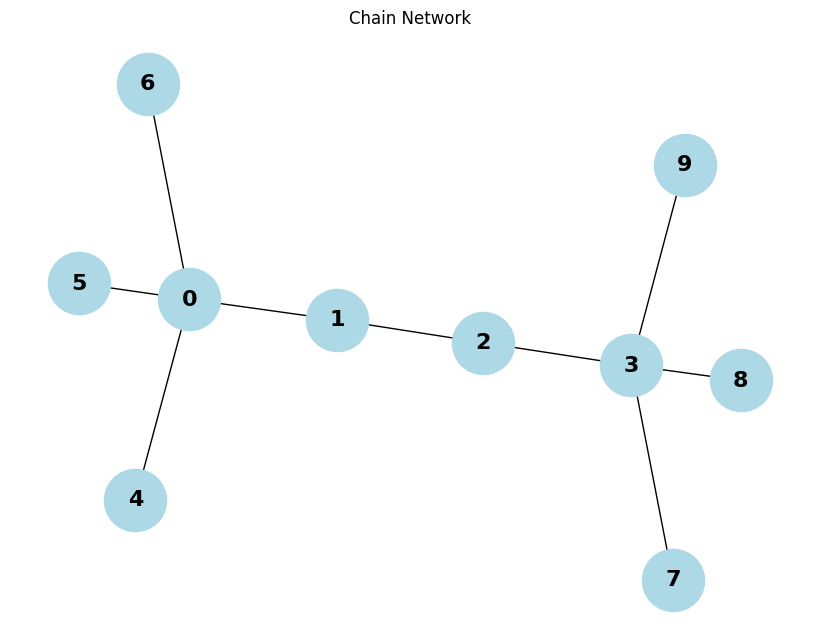

In the code cell below, a barbell network with 10 nodes (indices [0,9]) in the _bar_ has been created along with other parameters for generatin the random walks.

set the values of `qvals` to be list of values that ranges from 0.2 to 2.0. Then for each value of `qvals` use the `b_walks` in a call to the  `empirical_distribution` function to obtain the probability of visiting the different nodes in the graph. Create a plot of the probability of vising node 9 (this is one end of the bar) when starting at node 0 (this is at the other end of the bar) for the different q values. You should see the probability is higher for smaller (<1) values of q, noting that here, we hold `p=1` fixed.

In [ ]:
##################################
#### DO NOT MODIFY THIS CODE #####
##################################
# create a chain network 0-1-2-...-n
num_nodes = 10
adj_list = barbell_network(num_nodes=num_nodes, num_border_nodes=3)
total_walks = 1000
steps_per_walk = 50

##################################
### YOUR CODE HERE ###
##################################
q_vals = None  # YOUR CODE HERE

# plot probability of visiting node 9 for p = 1 for different q_vals
prob_node_9 = []
for q in q_vals:
    b_walks = random_walks(adj_list, start_node=0, num_steps=steps_per_walk, num_walks=total_walks, biased=True, p=1, q=q)
    # YOUR CODE HERE, get probability of visiting node 9 and add to prob_node_9. HINT: use empirical_distribution

# YOUR CODE HERE, plot probability of visiting node 9 for different values of q


---

# Excercise 4: PyG Node2Vec Application (4 points)
In this exercise, you are asked to apply the PyTorch Geometric nod2vec model to the CiteSeer citation network. Nodes in CiteSeer are papers and two nodes are connected by an edge if one of the papers cites the other. The dataset can be loaded by running the cell below. This exercise has three parts:
* (a)(2 points)Node2vec model training method
* (b)(1 point)Node2vec model setup
* (b)(1 point)Plot the validation loss observed during the training epochs

First, runt the cell below to load the CiteSeer data.

In [ ]:
##################################
#### DO NOT MODIFY THIS CODE #####
##################################
citeseer = Planetoid(root=DATA_DIR, name="CiteSeer")[0]
citeseer_class_names = ['Agents', 'AI', 'Database', 'Human-Computer Interaction', 'Machine Learning', 'Information Retrieval']
citeseer

### 4(a) Node2Vec Training
In the cell below, you are asked to:
* Complete implementation of the `train_node2vec` method which should update the model embeddings using the provided optimizer and data loader (refer to lab 03)

In [ ]:
def train_node2vec(model, num_epochs, batch_size, learning_rate, optimizer=None, loader=None):
    ##################################
    #### DO NOT MODIFY THIS CODE #####
    ##################################
    model.train()
    losses = []
    if optimizer is None:
        optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=learning_rate)
    if loader is None:
        loader = model.loader(batch_size=batch_size, shuffle=True, num_workers=0)

    #### YOUR CODE HERE #####
    for epoch in range(num_epochs):
        pass

    return losses

### 4(b) Node2Vec model setup
In the code cell below, perform the following:
* construct the node2vec model using the `node2vec_model` variable and the PyG `Node2Vec` class with the citeseer data and the following parameters:
    - `embedding_dim` : 64
    - `walk_length` : 30
    - `context_size` : 10
    - `walks_per_node` : 20
    - `p` : 1.5
    - `q` : 1.2
    - `num_negative_samples` : 10
* Train the model using the `train_node2vec` method you implemented in the previouis step using:
    - `num_epochs` : 20
    - `batch_size` : 32
    - `learning_rate` : 0.01

Make sure to save the lossess from `train_node2vec` in the `losses` variable

In [ ]:
node2vec_model = None #### YOUR CODE HERE ####

losses = None #### YOUR CODE HERE ####

##################################
#### DO NOT MODIFY THIS CODE #####
##################################
# Get embeddings for all nodes
node2vec_model.eval()
with torch.no_grad():
    embeddings = node2vec_model()

### 4(c) Plot Training Losses
In the code cell below, plot the losses observed during node2vec training.

In [ ]:
 #### YOUR CODE HERE ####

---

# Exercise 5: Implement, train, and evaluate CiteCeer Node Classification Model (5 points)
In this exercise, you are asked to develop a neural network model to predict the class label of an input node embedding from the CiteCeer network. This exercise has three parts:
* (a)(3 points) Implement the classifier training method
* (b)(1 point) Implement and train classifier
* (c)(1 pont) Evaluate classifier performance

First, execute the cell below to construct the training, validation, and test data splits.

In [ ]:
##################################
#### DO NOT MODIFY THIS CODE #####
##################################
split_params = {
    'num_train_per_class': 10,
    'num_val': int(0.1 * len(citeseer.x)),
    'num_test': int(0.2 * len(citeseer.x))
}

transform = RandomNodeSplit(**split_params, split='train_rest')
data_split = transform(citeseer.clone())

train_mask = data_split.train_mask
val_mask = data_split.val_mask
test_mask = data_split.test_mask

print(f"\nLab split results:")
print(f"Training nodes: {train_mask.sum().item()}")
print(f"Validation nodes: {val_mask.sum().item()}")
print(f"Test nodes: {test_mask.sum().item()}")

# Show class distribution in lab training set
train_labels = citeseer.y[train_mask]
citeseer_labels = set([_.item() for _ in citeseer.y.numpy().astype(int)])
print(citeseer_labels)

X_train = embeddings[train_mask].detach().to(device)
y_train = citeseer.y[train_mask].to(device)
X_val = embeddings[val_mask].detach().to(device)
y_val = citeseer.y[val_mask].to(device)
X_test = embeddings[test_mask].detach().to(device)
y_test = citeseer.y[test_mask].to(device)

### 5(a) Implement classifier training method
In the code cell below, you are aksed to complete the `train_classifier` method using the provided loss function `loss_func`, `optimizer`, and batch data loader, `loader`. The method should store the average train loss over the batches for each epoch. It should also compute and store the validation loss after each epoch. (refer to lab 03)

In [ ]:
def train_classifier(model, X_train, y_train, X_val, y_val, num_epochs, learning_rate, batch_size,
                     loss_func=None, optimizer=None, loader=None):

    ##################################
    #### DO NOT MODIFY THIS CODE #####
    ##################################
    # Get device from model
    device = next(model.parameters()).device

    # Ensure all data is on the correct device
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_val = X_val.to(device)
    y_val = y_val.to(device)

    if loss_func is None:
        loss_func = tnn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    if loader is None:
        loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    train_losses = []
    val_losses = []

    #### YOUR CODE HERE #####
    for epoch in range(num_epochs):
        pass

    return train_losses, val_losses

### 5(b) Implement and train CiteSeer node classifier
In the code cell below, perform the following:
* Implement the `CiteSeerClassifier` class, which extends the `torch.nn.Module` class, to model a neural network classifier. The model should contain the following components:
    * a fully connected linear layer
    * a rectified linear unit activation
    * an output linear layer
* Create and train an instance of the `CiteSeerClassifier` method using the `train_classifier` method you implemented in the previous step using:
    - `hidden_dim` : 64
    - `num_epochs` : 20
    - `learning_rate` : 0.01
    - `batch_size` : 128
    
    


In [ ]:
class CiteSeerClassifier(tnn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        #### YOUR CODE HERE ####
        pass

    def forward(self, x):
        #### YOUR CODE HERE ####
        pass

#### YOUR CODE HERE ####
model = None

train_losses1, val_losses1 = None

### 5(c) CiteSeer node classification performance
Finally, in the code cell below, use the trained model to obtain predictions for the test set. Use the predicted values to print the classification performance with the scikit-learn `classification_report` method.

In [ ]:
#### YOUR CODE HERE ####